# Google Playstore Apps Data Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data=pd.read_excel('googleplaystore.xlsx')
pd.set_option('display.max_columns' , None) # used for displaying max columns
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


# Removing Duplicates and Cleaning the data

In [7]:
data.duplicated().sum()

np.int64(483)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.isnull().sum()

App                  1
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

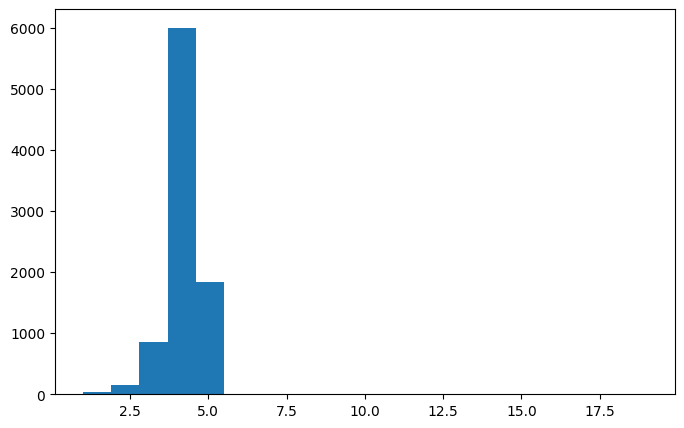

In [11]:
plt.figure(figsize=(8,5))
plt.hist(data['Rating'], bins=20)
plt.show()

In [12]:
median=data['Rating'].median()
median

np.float64(4.3)

In [13]:
data.fillna({'Rating' : median} , inplace=True)

In [14]:
data.isnull().sum()

App               1
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [15]:
data.dropna(subset=['App' , 'Type' , 'Content Rating' , 'Current Ver' , 'Android Ver' ]  , inplace=True)

In [16]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10345 non-null  object 
 1   Category        10345 non-null  object 
 2   Rating          10345 non-null  float64
 3   Reviews         10345 non-null  object 
 4   Size            10345 non-null  object 
 5   Installs        10345 non-null  object 
 6   Type            10345 non-null  object 
 7   Price           10345 non-null  object 
 8   Content Rating  10345 non-null  object 
 9   Genres          10345 non-null  object 
 10  Last Updated    10345 non-null  object 
 11  Current Ver     10345 non-null  object 
 12  Android Ver     10345 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


# Changing the Data Types for proper Operations

In [18]:
data['Reviews']=data['Reviews'].astype(int) #Changing Data Type

In [19]:
data['Installs']=data['Installs'].str.replace('+' , '') #Replacing signs with Proper Values for mathematical calculation and graphs

In [20]:
data['Installs']=data['Installs'].str.replace(',' , '')

In [21]:
data['Installs']=data['Installs'].astype(int)

In [22]:
data['Reviews']=data['Reviews'].astype(int)

In [23]:
data['Size']=data['Size'].str.replace('M' , '1000000')#Replacing signs with Proper Values for mathematical calculation and graphs

In [24]:
data['Size']=data['Size'].str.replace('k' , '1000')

In [25]:
data['Size'] = data['Size'].replace('Varies with device', np.nan)


In [26]:
data['Size']=data['Size'].astype(float)

In [27]:
Med=data['Size'].median()

In [28]:
data.fillna({'Size' : Med } , inplace=True)

In [29]:
data['Price']=data['Price'].str.replace('$' , '') #use reflex cause python confuse $ with end line function.


In [30]:
data['Price'].isnull().sum()

np.int64(9583)

In [31]:
data.fillna({'Price' : 0} , inplace=True)

In [32]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1.910000e+08,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1.410000e+08,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.710000e+00,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2.510000e+08,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.810000e+00,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,5.310000e+08,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.610000e+00,100,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.510000e+00,1000,Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,1.310000e+08,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [33]:
data['Price']=data['Price'].astype(float)

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10345 non-null  object 
 1   Category        10345 non-null  object 
 2   Rating          10345 non-null  float64
 3   Reviews         10345 non-null  int64  
 4   Size            10345 non-null  float64
 5   Installs        10345 non-null  int64  
 6   Type            10345 non-null  object 
 7   Price           10345 non-null  float64
 8   Content Rating  10345 non-null  object 
 9   Genres          10345 non-null  object 
 10  Last Updated    10345 non-null  object 
 11  Current Ver     10345 non-null  object 
 12  Android Ver     10345 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [35]:
data['Last Updated'] = pd.to_datetime(data['Last Updated'])

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10345 non-null  object        
 1   Category        10345 non-null  object        
 2   Rating          10345 non-null  float64       
 3   Reviews         10345 non-null  int64         
 4   Size            10345 non-null  float64       
 5   Installs        10345 non-null  int64         
 6   Type            10345 non-null  object        
 7   Price           10345 non-null  float64       
 8   Content Rating  10345 non-null  object        
 9   Genres          10345 non-null  object        
 10  Last Updated    10345 non-null  datetime64[ns]
 11  Current Ver     10345 non-null  object        
 12  Android Ver     10345 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 1.1+ MB


In [37]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1.910000e+08,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1.410000e+08,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.710000e+00,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2.510000e+08,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.810000e+00,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,5.310000e+08,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.610000e+00,100,Free,0.0,Everyone,Education,2018-07-06,1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.510000e+00,1000,Free,0.0,Everyone,Medical,2017-01-20,1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,1.310000e+08,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device


In [38]:
data.sort_values(by='Reviews' , ascending=False , inplace=True)

In [39]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2544,Facebook,SOCIAL,4.1,78158306,1.310000e+08,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device
3943,Facebook,SOCIAL,4.1,78128208,1.310000e+08,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,1.310000e+08,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device
3904,WhatsApp Messenger,COMMUNICATION,4.4,69109672,1.310000e+08,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device
2604,Instagram,SOCIAL,4.5,66577446,1.310000e+08,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5457,AP Mobile 104,BUSINESS,4.3,0,1.410000e+08,100,Free,0.0,Everyone,Business,2017-12-13,1.2.2.0,4.0 and up
6530,BN Habitat - Property Experts - Buy | Sell | Rent,BUSINESS,4.3,0,8.910000e+00,50,Free,0.0,Everyone,Business,2017-10-04,1.8,4.1 and up
10110,Adhenarcos - Coupe Adhemar EY 2018,FAMILY,4.3,0,1.310000e+08,100,Free,0.0,Teen,Entertainment,2018-01-10,1,4.1 and up
5921,BA SALES,COMMUNICATION,4.3,0,2.910000e+00,1,Free,0.0,Everyone,Communication,2018-01-31,1,4.0.3 and up


In [40]:
data.drop_duplicates(subset=['App'] , inplace=True)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9647 entries, 2544 to 6502
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9647 non-null   object        
 1   Category        9647 non-null   object        
 2   Rating          9647 non-null   float64       
 3   Reviews         9647 non-null   int64         
 4   Size            9647 non-null   float64       
 5   Installs        9647 non-null   int64         
 6   Type            9647 non-null   object        
 7   Price           9647 non-null   float64       
 8   Content Rating  9647 non-null   object        
 9   Genres          9647 non-null   object        
 10  Last Updated    9647 non-null   datetime64[ns]
 11  Current Ver     9647 non-null   object        
 12  Android Ver     9647 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 1.0+ MB


In [42]:
data.reset_index(drop=True, inplace=True)

In [43]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Facebook,SOCIAL,4.1,78158306,1.310000e+08,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,1.310000e+08,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device
2,Instagram,SOCIAL,4.5,66577446,1.310000e+08,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device
3,Messenger â€“ Text and Video Chat for Free,COMMUNICATION,4.0,56646578,1.310000e+08,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device
4,Clash of Clans,GAME,4.6,44893888,9.810000e+08,100000000,Free,0.0,Everyone 10+,Strategy,2018-07-15,10.322.16,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9642,AP Mobile 104,BUSINESS,4.3,0,1.410000e+08,100,Free,0.0,Everyone,Business,2017-12-13,1.2.2.0,4.0 and up
9643,BN Habitat - Property Experts - Buy | Sell | Rent,BUSINESS,4.3,0,8.910000e+00,50,Free,0.0,Everyone,Business,2017-10-04,1.8,4.1 and up
9644,Adhenarcos - Coupe Adhemar EY 2018,FAMILY,4.3,0,1.310000e+08,100,Free,0.0,Teen,Entertainment,2018-01-10,1,4.1 and up
9645,BA SALES,COMMUNICATION,4.3,0,2.910000e+00,1,Free,0.0,Everyone,Communication,2018-01-31,1,4.0.3 and up


# Business Related Question

# Generes With Most Apps

In [44]:
group1=data.groupby('Category')['App'].count().reset_index()

In [45]:
group1

,Category,App
0,ART_AND_DESIGN,60
1,AUTO_AND_VEHICLES,85
2,BEAUTY,53
3,BOOKS_AND_REFERENCE,221
4,BUSINESS,420
5,COMICS,55
6,COMMUNICATION,315
7,DATING,170
8,EDUCATION,106
9,ENTERTAINMENT,86


<BarContainer object of 33 artists>

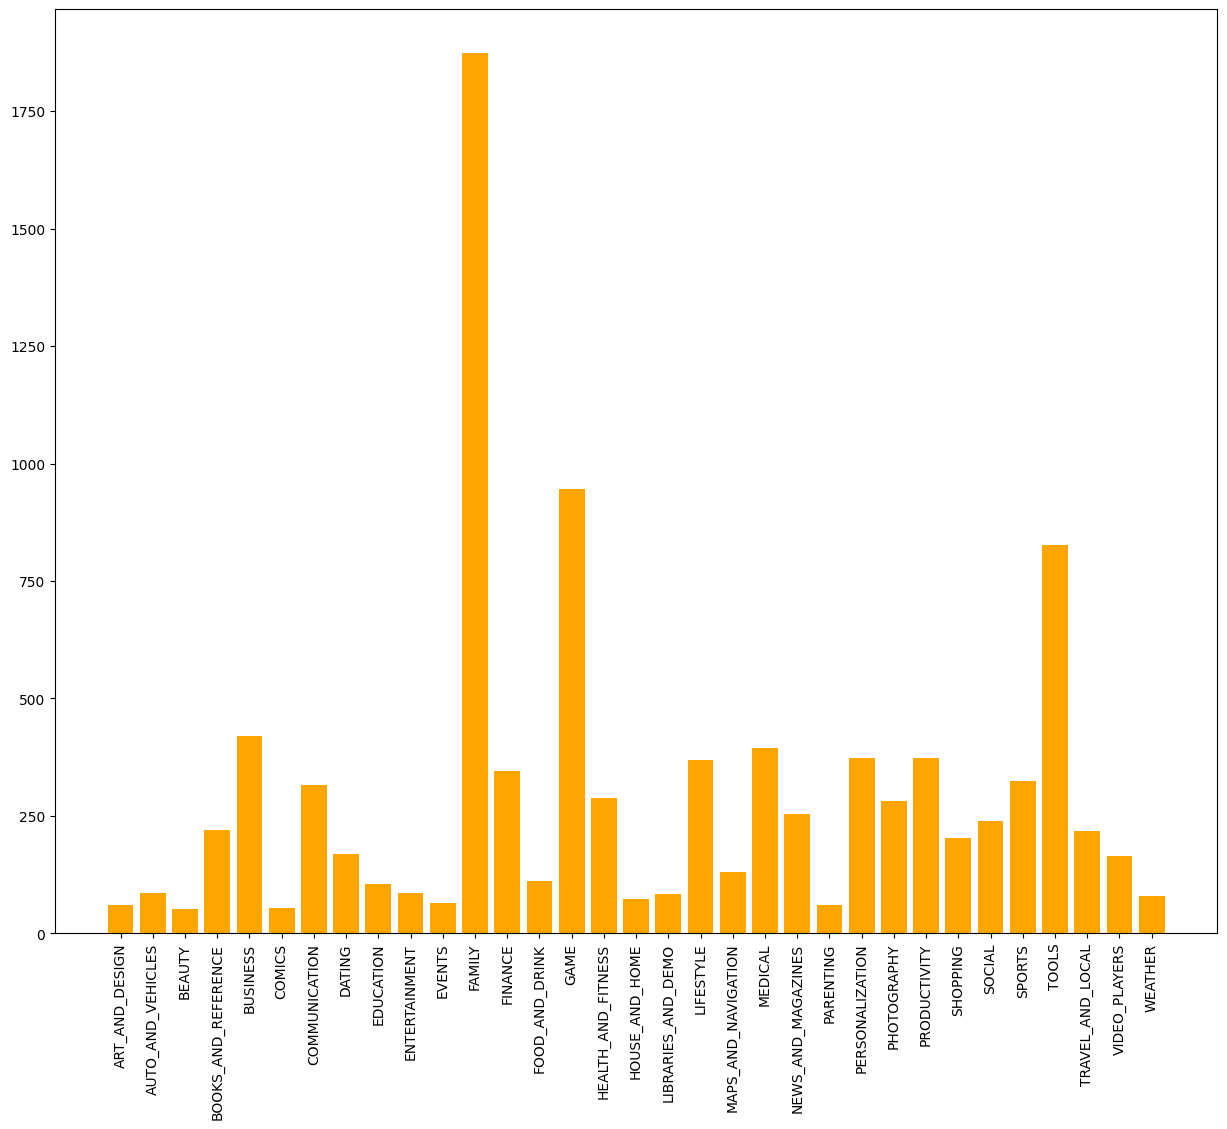

In [72]:
plt.figure(figsize=(15,12))
plt.xticks(rotation=90)
plt.bar(group1['Category'] , group1['App'] , color='Orange')

# Free vs Paid Apps

In [47]:
group2=data.groupby('Type')['App'].count().reset_index()

In [48]:
group2

,Type,App
0,Free,8896
1,Paid,751


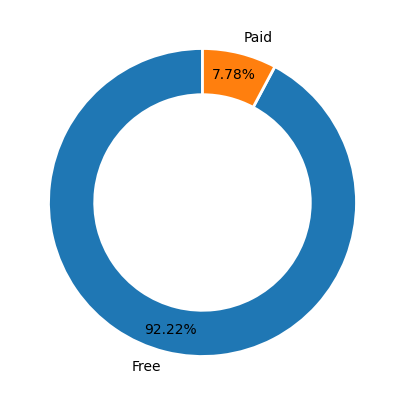

In [49]:
plt.figure(figsize=(9,5))

labels = ['Free' , 'Paid']
plt.pie(group2['App'],labels=labels,autopct='%1.2f%%' , startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})


plt.show()

# Content Rating in Apps

In [50]:
group3=data.groupby('Content Rating')['App'].count().reset_index()
group3

,Content Rating,App
0,Adults only 18+,3
1,Everyone,7893
2,Everyone 10+,321
3,Mature 17+,392
4,Teen,1036
5,Unrated,2


<BarContainer object of 6 artists>

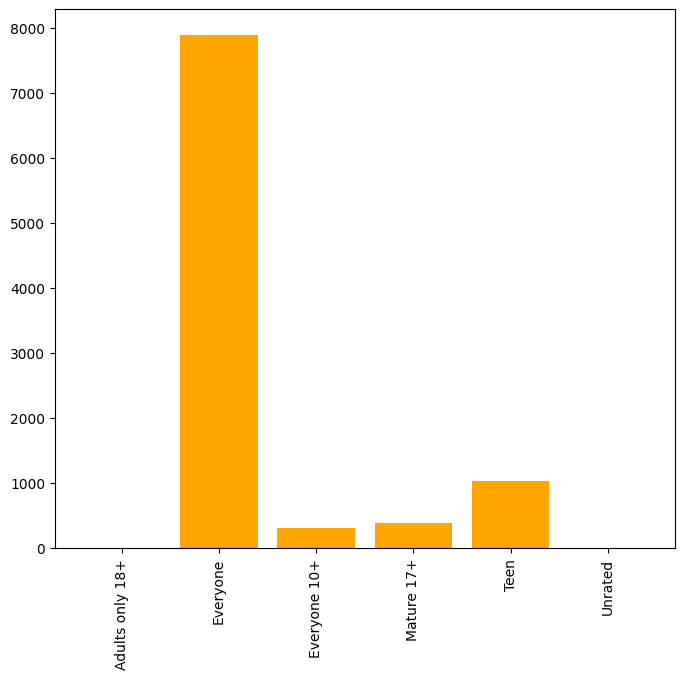

In [51]:
plt.figure(figsize=(8,7))
plt.xticks(rotation=90)
plt.bar(group3['Content Rating'] , group3['App'] , color='Orange')

# Top 10 most installed apps

In [52]:
group4=data.groupby('App')['Installs'].sum().reset_index()
group4.sort_values(by='Installs' , ascending=False ,  inplace=True)
group5=group4.head(15)
group5

,App,Installs
4933,Google Play Books,1000000000
9214,YouTube,1000000000
5394,Instagram,1000000000
4907,Google,1000000000
4323,Facebook,1000000000
4864,Gmail,1000000000
4935,Google Play Movies & TV,1000000000
4939,Google Street View,1000000000
4934,Google Play Games,1000000000
4916,Google Chrome: Fast & Secure,1000000000


# Average Rating By Category

In [56]:
group6=data.groupby('Category')['Rating'].mean().reset_index()
group6

,Category,Rating
0,ART_AND_DESIGN,4.376667
1,AUTO_AND_VEHICLES,4.205882
2,BEAUTY,4.283019
3,BOOKS_AND_REFERENCE,4.334389
4,BUSINESS,4.173810
5,COMICS,4.198182
6,COMMUNICATION,4.154921
7,DATING,4.050000
8,EDUCATION,4.350943
9,ENTERTAINMENT,4.129070


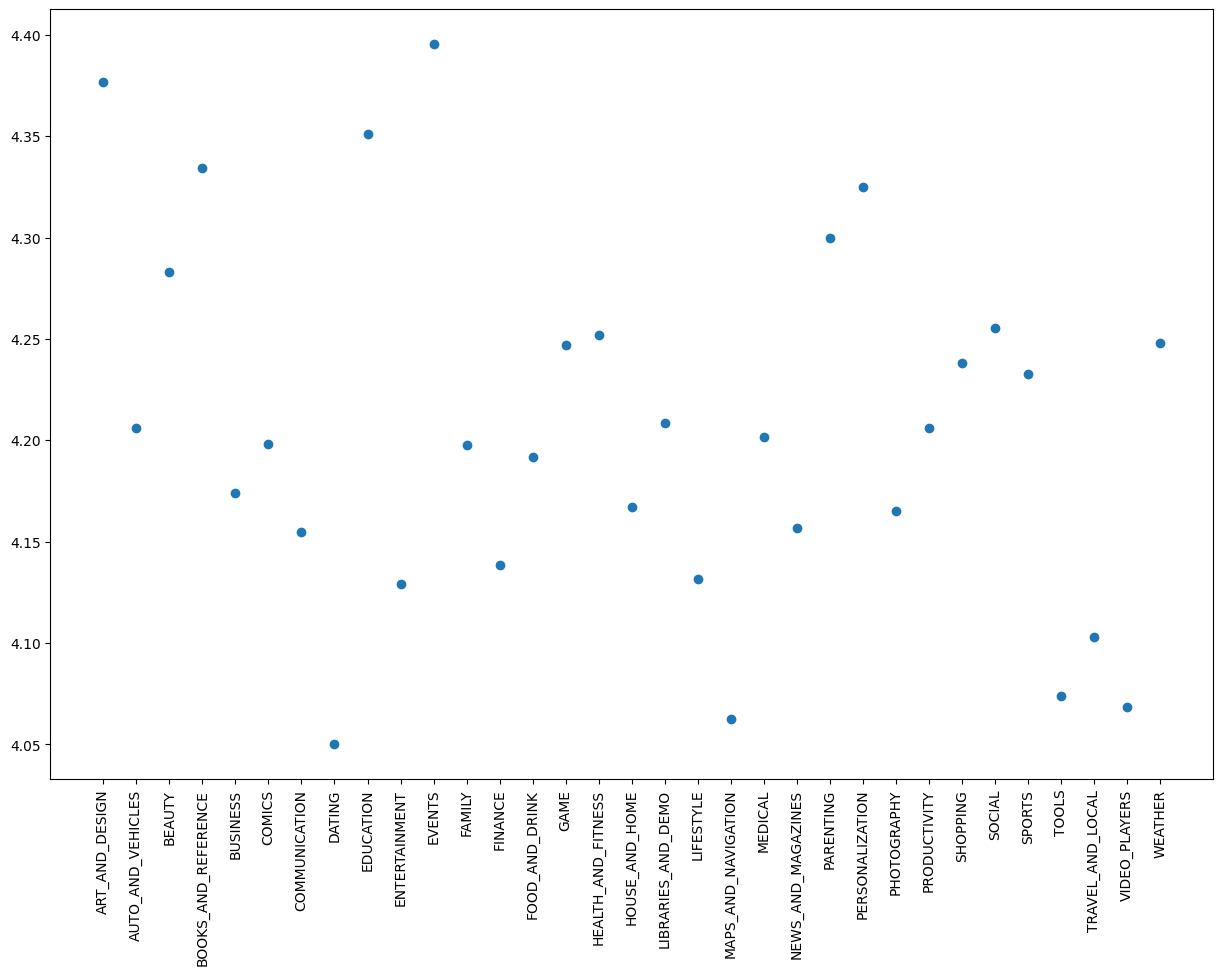

In [64]:
plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
plt.scatter(group6['Category'] , group6['Rating'])

# Review VS Rating 


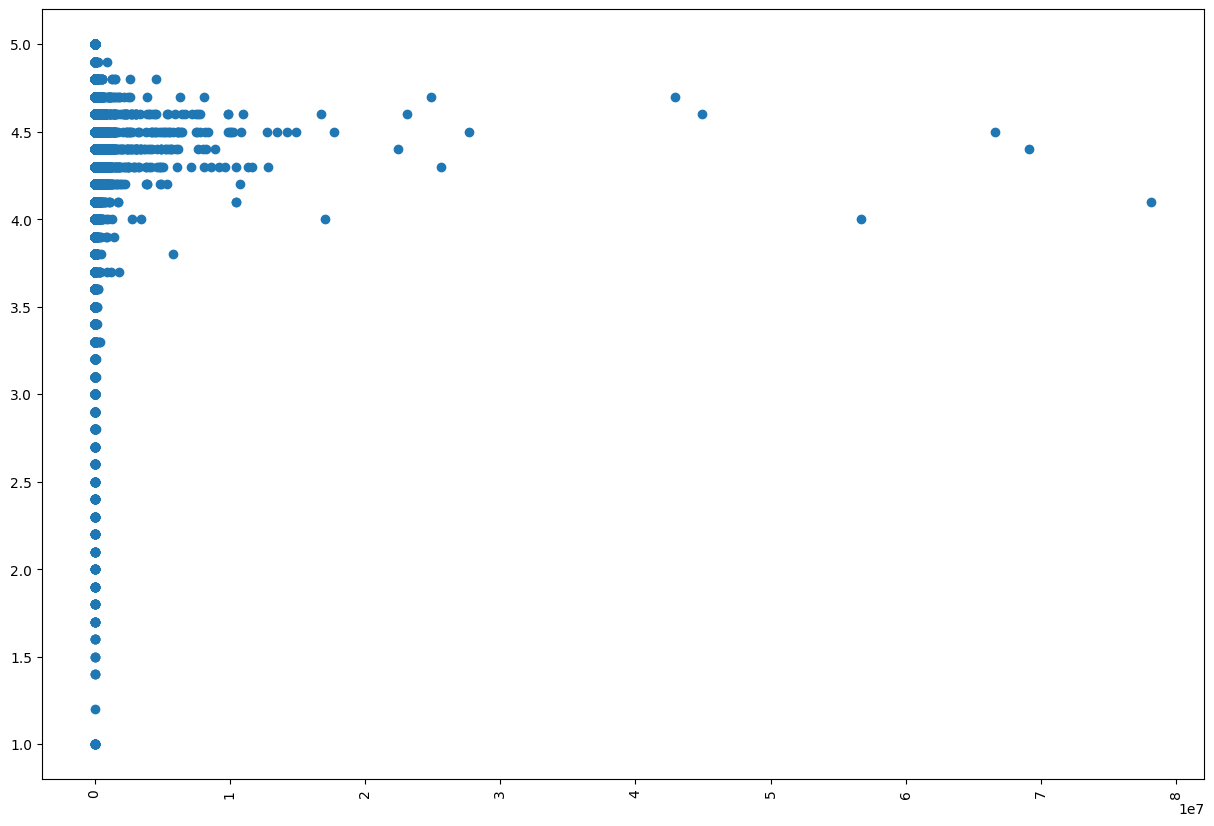

In [67]:
plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
plt.scatter(data['Reviews'] , data['Rating'])

# Average App Size by Category

In [68]:
group7=data.groupby('Category')['Size'].mean().reset_index()
group7

,Category,Size
0,ART_AND_DESIGN,9.630000e+07
1,AUTO_AND_VEHICLES,1.740219e+08
2,BEAUTY,1.122075e+08
3,BOOKS_AND_REFERENCE,1.061482e+08
4,BUSINESS,1.150016e+08
5,COMICS,1.209915e+08
6,COMMUNICATION,1.012826e+08
7,DATING,1.310305e+08
8,EDUCATION,1.567342e+08
9,ENTERTAINMENT,1.906047e+08


<BarContainer object of 33 artists>

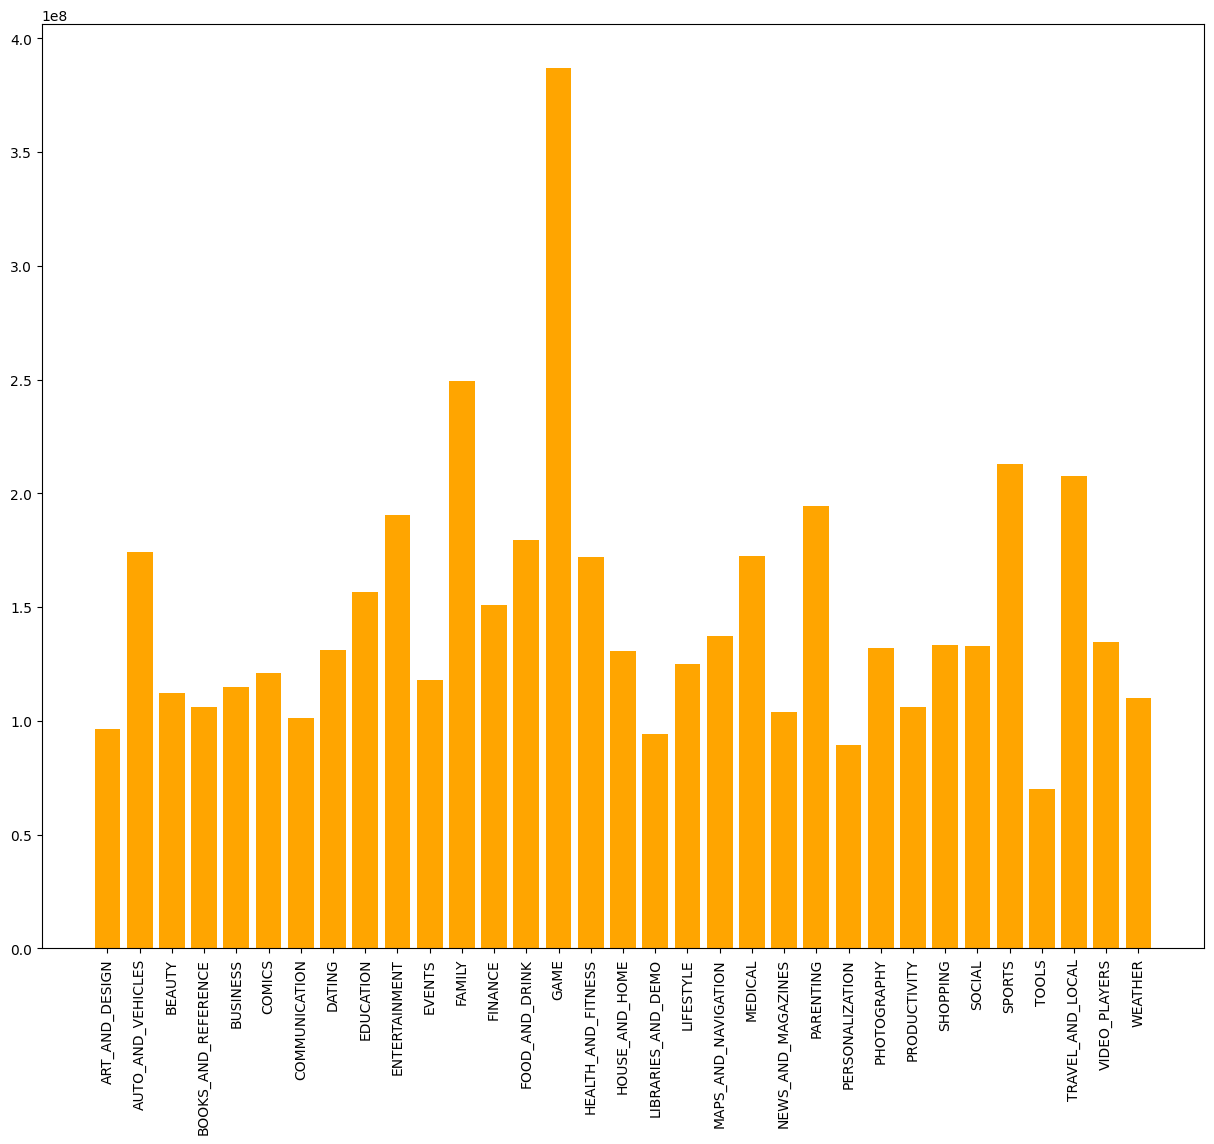

In [71]:
plt.figure(figsize=(15,12))
plt.xticks(rotation=90)
plt.bar(group7['Category'] , group7['Size'] , color='Orange')

# Average Installs: Free vs Paid

In [77]:
group8=data.groupby('Type')['Installs'].mean().reset_index()
group8

,Type,Installs
0,Free,8.460390e+06
1,Paid,7.631527e+04


<BarContainer object of 2 artists>

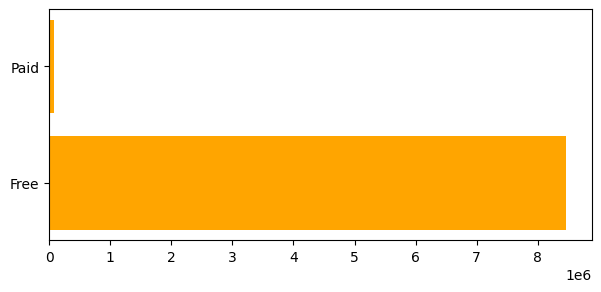

In [79]:
plt.figure(figsize=(7,3))

plt.barh(group8['Type'] , group8['Installs'] , color='Orange')

# Android Version Requirement

In [83]:
group9=data.groupby('Android Ver')['App'].count().reset_index()
group9

,Android Ver,App
0,1.0 and up,2
1,1.5 and up,19
2,1.6 and up,115
3,2.0 and up,31
4,2.0.1 and up,7
5,2.1 and up,133
6,2.2 - 7.1.1,1
7,2.2 and up,239
8,2.3 and up,613
9,2.3.3 and up,273


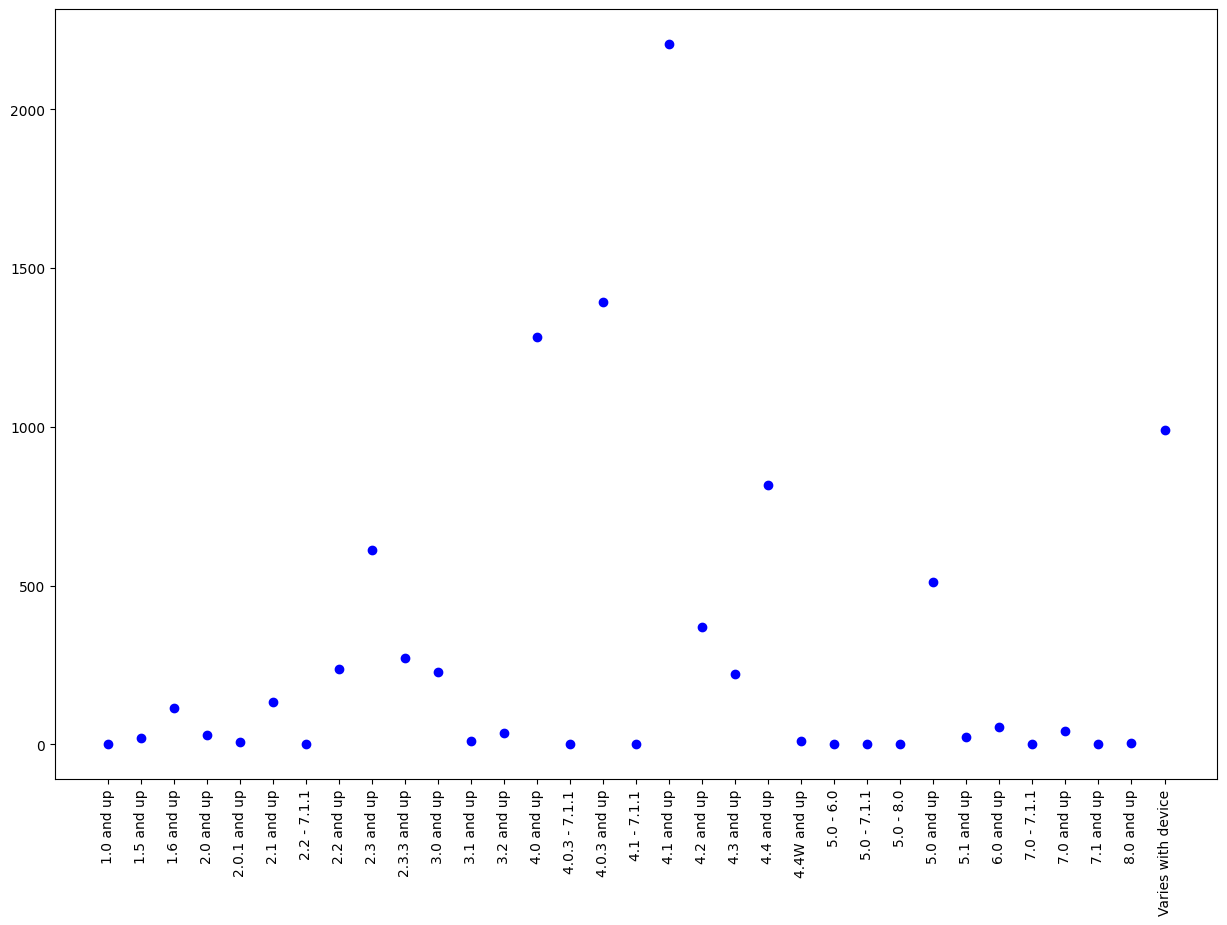

In [89]:
plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
plt.scatter(group9['Android Ver'] , group9['App'] , color='Blue')

# Average Price by Category (Paid Apps)

In [93]:
paid = data[data['Type']=='Paid']
price = paid.groupby('Category')['Price'].mean().reset_index()
price

,Category,Price
0,ART_AND_DESIGN,1.990000
1,AUTO_AND_VEHICLES,4.490000
2,BOOKS_AND_REFERENCE,4.277500
3,BUSINESS,14.607500
4,COMMUNICATION,3.079259
5,DATING,4.090000
6,EDUCATION,3.990000
7,ENTERTAINMENT,3.990000
8,EVENTS,109.990000
9,FAMILY,13.091576


<BarContainer object of 30 artists>

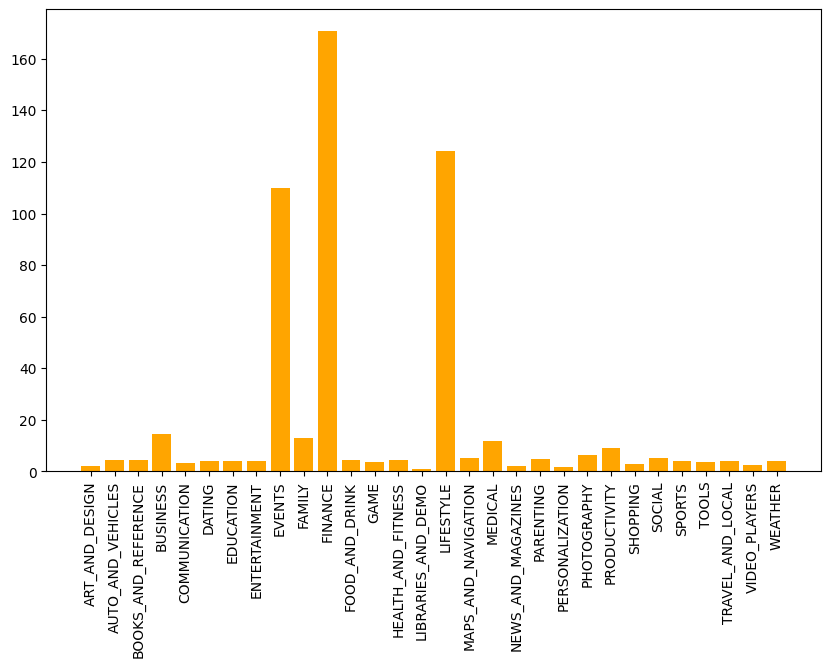

In [98]:
plt.figure(figsize=(10,6))
plt.xticks(rotation=90)
plt.bar(price['Category'] , price['Price'] , color='Orange')